# TP3: Histogram Processing, Edge Detection, and Morphology

Histogram operations, gradient-based edge detection with Sobel, frequency-domain filtering, and morphological operations.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


## 1. Load cameraman.jpeg

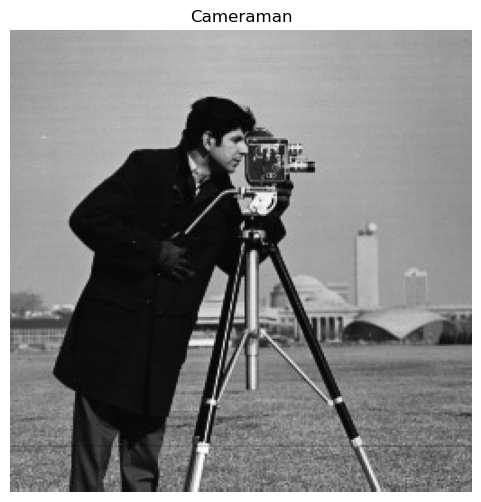

In [2]:
image = cv2.imread("cameraman.jpeg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Cameraman")
plt.axis("off")
plt.show()


## 2. Plot histogram

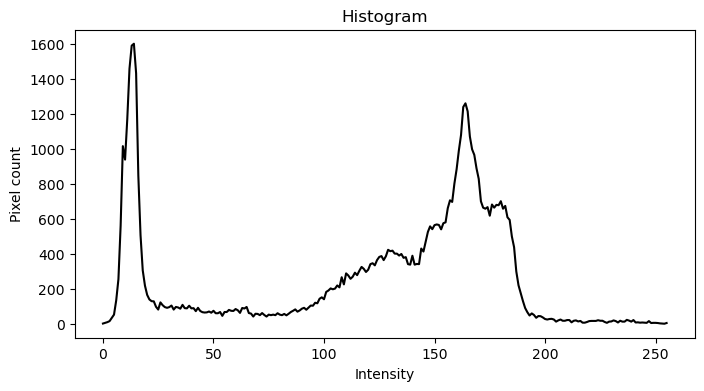

In [3]:
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist, color="black")
plt.title("Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.show()


## 3. Histogram shift (brightness adjustment)

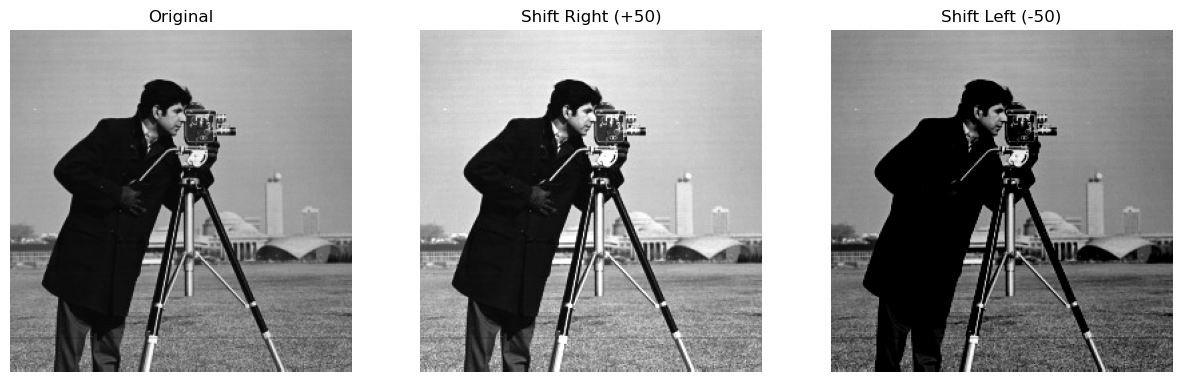

In [4]:
shifted_right = cv2.add(image, 50)
shifted_left  = cv2.subtract(image, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(shifted_right, cmap="gray"); axes[1].set_title("Shift Right (+50)"); axes[1].axis("off")
axes[2].imshow(shifted_left, cmap="gray"); axes[2].set_title("Shift Left (-50)"); axes[2].axis("off")
plt.show()


## 4. Cumulative histogram

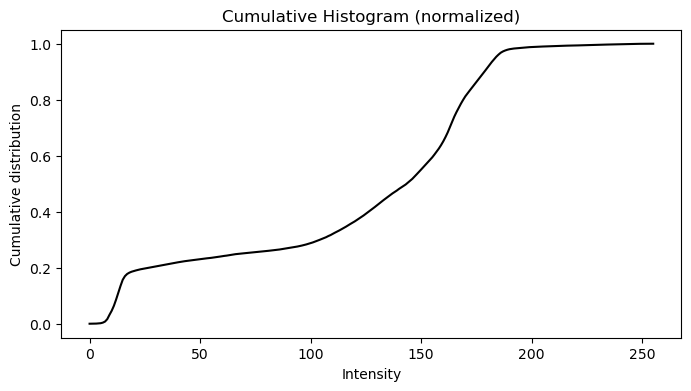

In [5]:
hist_cum = hist.cumsum() / hist.cumsum().max()

plt.figure(figsize=(8, 4))
plt.plot(hist_cum, color="black")
plt.title("Cumulative Histogram (normalized)")
plt.xlabel("Intensity")
plt.ylabel("Cumulative distribution")
plt.show()


## 5. Manual histogram equalization on thumb_pout.png

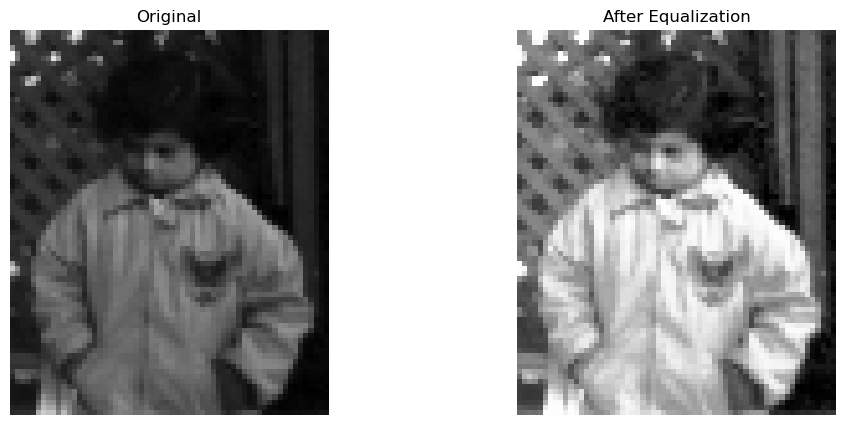

In [6]:
img_pout = cv2.imread("thumb_pout.png", cv2.IMREAD_GRAYSCALE)
h, w = img_pout.shape

hist_p = cv2.calcHist([img_pout], [0], None, [256], [0, 256])
cdf = (255 * hist_p.cumsum()) / (w * h)
equalized = np.interp(img_pout, np.arange(256), cdf).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_pout, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(equalized, cmap="gray"); axes[1].set_title("After Equalization"); axes[1].axis("off")
plt.show()


## 6-9. Sobel edge detection on trui.png

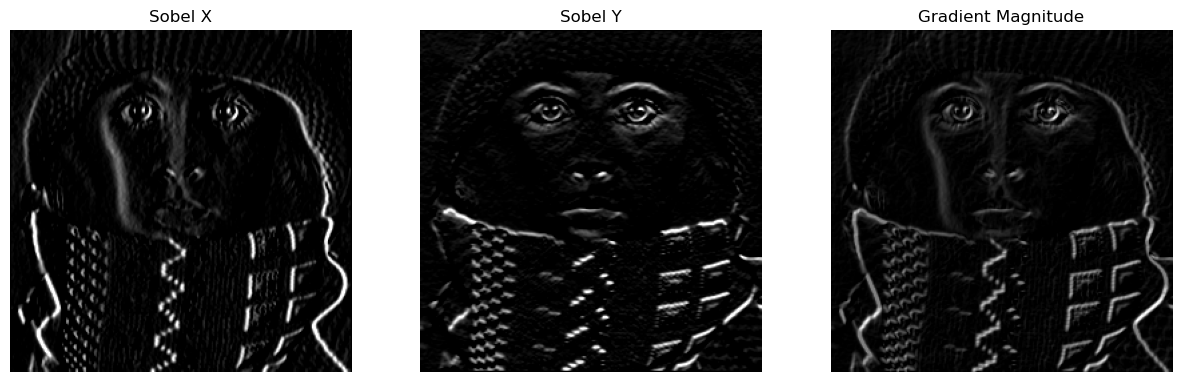

In [7]:
trui = cv2.imread("trui.png", cv2.IMREAD_GRAYSCALE)

sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

sobel_x = cv2.filter2D(trui, -1, sobel_x_kernel)
sobel_y = cv2.filter2D(trui, -1, sobel_y_kernel)
gradient = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sobel_x, cmap="gray"); axes[0].set_title("Sobel X"); axes[0].axis("off")
axes[1].imshow(sobel_y, cmap="gray"); axes[1].set_title("Sobel Y"); axes[1].axis("off")
axes[2].imshow(gradient, cmap="gray"); axes[2].set_title("Gradient Magnitude"); axes[2].axis("off")
plt.show()


## 10. Thresholded Sobel

MATLAB's `edge(img, 'sobel')` applies automatic thresholding after Sobel. Approximated here with a fixed threshold.

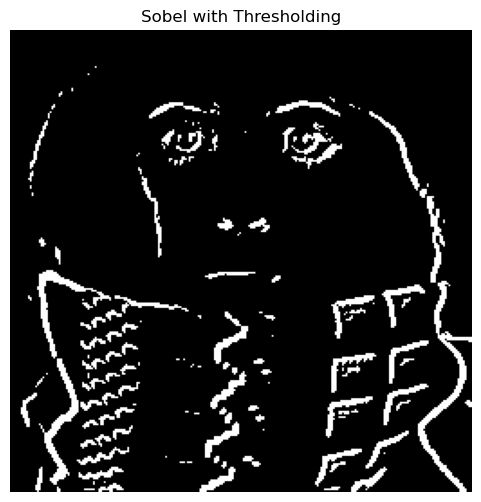

In [8]:
_, sobel_thresh = cv2.threshold(gradient, 50, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6, 6))
plt.imshow(sobel_thresh, cmap="gray")
plt.title("Sobel with Thresholding")
plt.axis("off")
plt.show()


## 11. Frequency-domain low-pass filtering

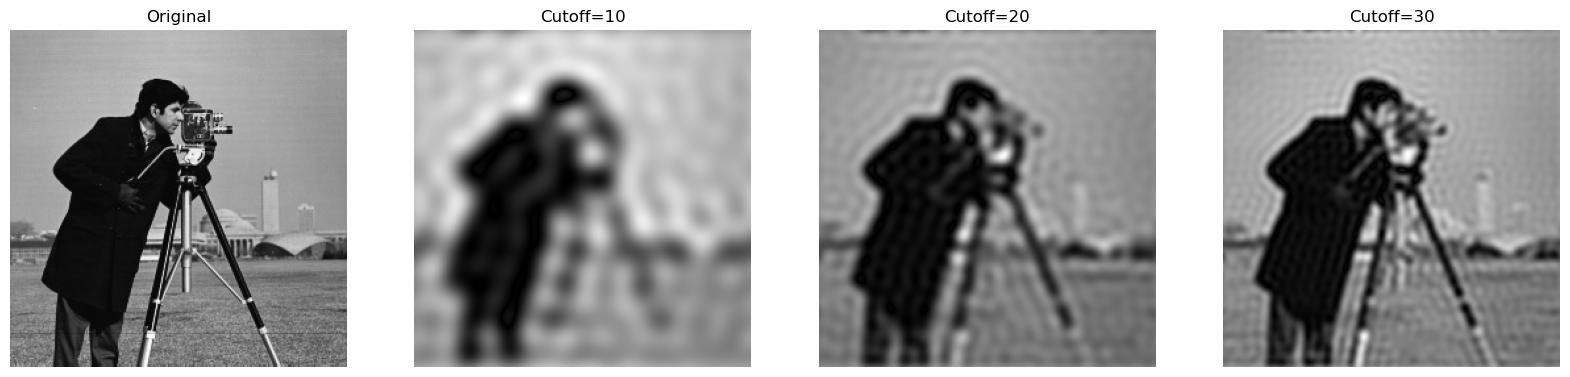

In [9]:
cam = cv2.imread("cameraman.jpeg", cv2.IMREAD_GRAYSCALE)
h_c, w_c = cam.shape
fshift = np.fft.fftshift(np.fft.fft2(cam))

cutoffs = [10, 20, 30]
fig, axes = plt.subplots(1, len(cutoffs) + 1, figsize=(20, 5))
axes[0].imshow(cam, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
for i, cutoff in enumerate(cutoffs):
    mask = np.zeros((h_c, w_c), np.uint8)
    cv2.circle(mask, (w_c // 2, h_c // 2), cutoff, 1, -1)
    filtered = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask)))
    axes[i+1].imshow(filtered, cmap="gray"); axes[i+1].set_title(f"Cutoff={cutoff}"); axes[i+1].axis("off")
plt.show()


## 12. Frequency-domain high-pass filtering

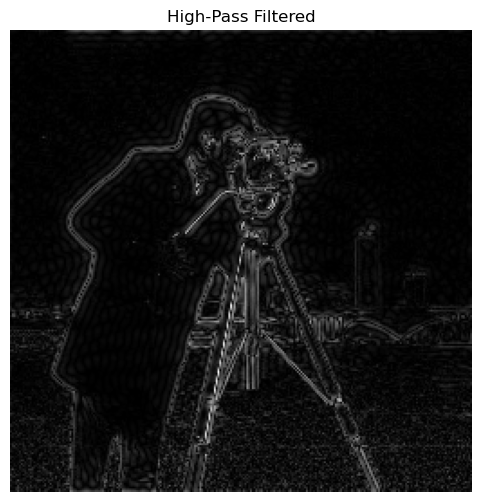

In [10]:
mask_lp = np.zeros((h_c, w_c), np.uint8)
cv2.circle(mask_lp, (w_c // 2, h_c // 2), 30, 1, -1)
filtered_hp = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * (1 - mask_lp))))

plt.figure(figsize=(6, 6))
plt.imshow(filtered_hp, cmap="gray")
plt.title("High-Pass Filtered")
plt.axis("off")
plt.show()


## 13. Morphological operations

5x5 rectangular structuring element applied to cameraman.

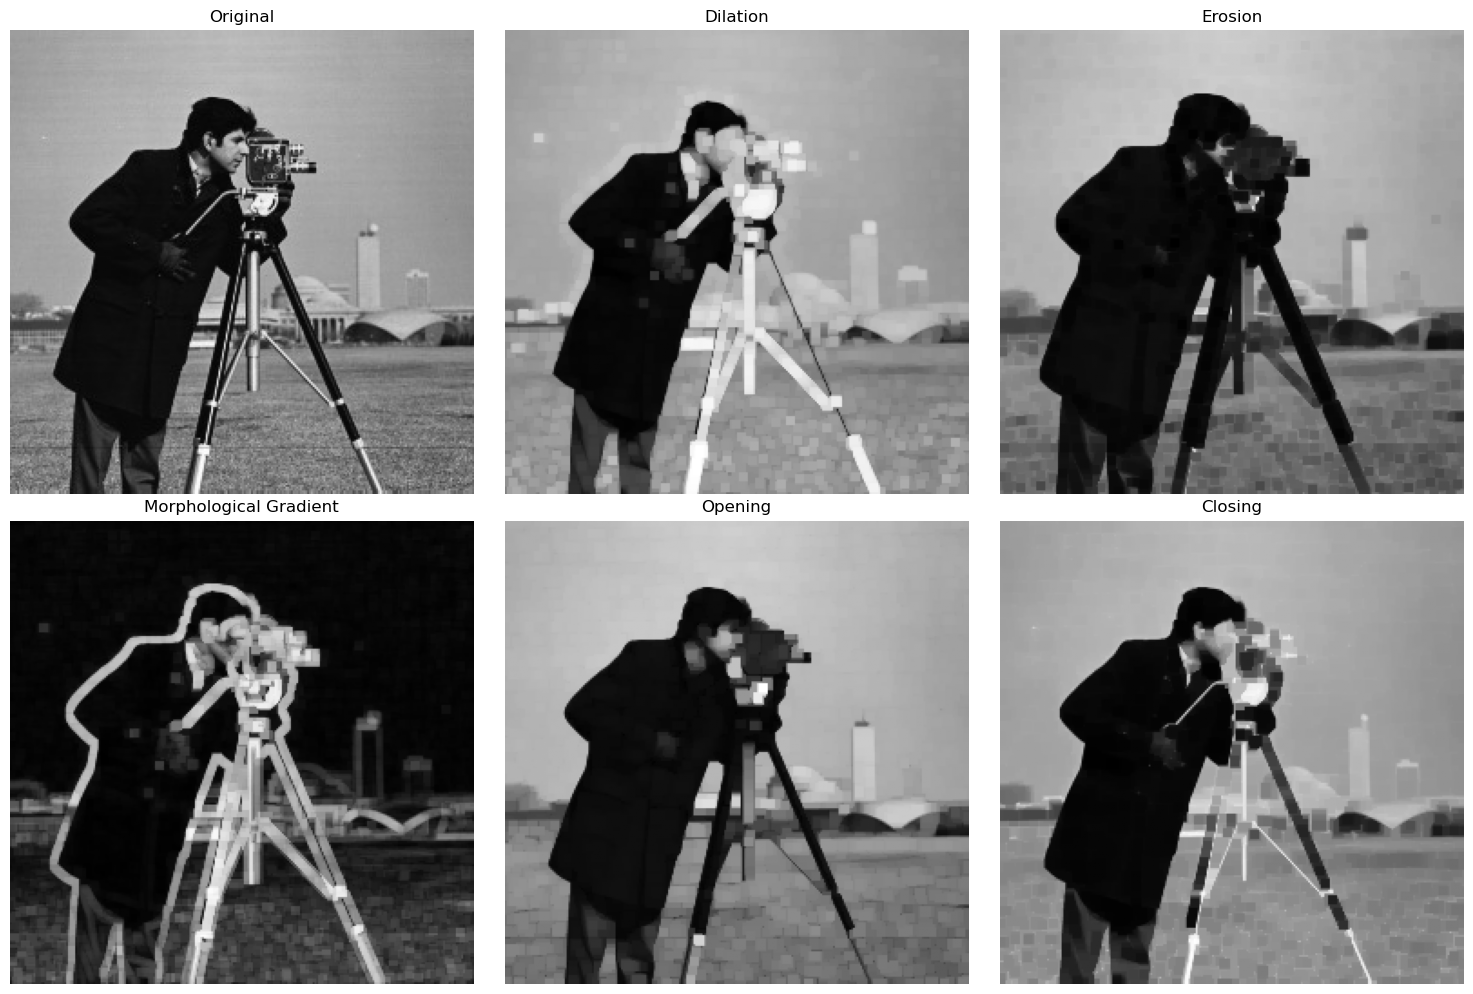

In [11]:
kernel_m = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

ops = [
    ("Original",             image),
    ("Dilation",             cv2.dilate(image, kernel_m)),
    ("Erosion",              cv2.erode(image, kernel_m)),
    ("Morphological Gradient", cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel_m)),
    ("Opening",              cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel_m)),
    ("Closing",              cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel_m)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (title, img) in zip(axes.ravel(), ops):
    ax.imshow(img, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout()
plt.show()
